# Task: Augmentation

**Student Name:** Mykhailo Andrusiak  
**Country:** Switzerland  
**Semester term:** FS26  

## Day 1 - Data and Domain

### Use Case

In the context of automated road sign recognition for Swiss urban traffic management, cameras deployed along Swiss roads capture images of traffic signs to support real-time speed limit enforcement, driver assistance systems, and ASTRA road monitoring infrastructure. These images are processed by sign detection algorithms to identify speed limits and directional information. This use case is particularly relevant for Switzerland because Swiss urban roads combine multiple sign types (speed limits, directional arrows, street names) at single locations, and reliable automated recognition is critical for both traffic safety enforcement and navigation systems.

### Problem Statement

This project addresses the problem of simulating and quantifying atmospheric and sensor degradation in road sign camera images. Cameras used for automated sign recognition frequently experience fog, rain, low-light conditions, and sensor noise. Under these conditions, sign text and numerals become progressively blurred and noisy, reducing the reliability of automated recognition. The speed limit numeral "40" on the circular sign in this image serves as the primary degradation indicator: it has well-defined edges and high-contrast text that becomes unreadable at a measurable level of degradation. Augmentation is needed to simulate these conditions systematically and assess at what degradation level automated sign recognition would fail.

### Experimental Objective

The objective of augmentation in this context is to simulate realistic atmospheric degradation (fog via Gaussian blur) and sensor degradation (additive Gaussian noise) as experienced by road sign recognition cameras. By systematically increasing degradation intensity across three configurations, we quantify at what level of simulated blur and noise the structural fidelity of the sign image becomes unacceptable for automated recognition, using SSIM as the evaluation measure. The speed limit sign "40" serves as the identifiable reference structure whose legibility anchors the practical interpretation of SSIM values.

### Data Definition, Source, and Visualization

The selected image is a photograph of a Swiss road sign cluster in Cologny, Geneva, showing a speed limit sign "40" (circular, red border, black numeral on white), directional signs ("Chêne", "La Capite / Thonon", "Fondation Martin Bodmer"), and a street name plate ("Rte de La-Capite"). The signs are photographed against a clear sky and building background with good illumination and high contrast. The **identifiable structure** is the speed limit sign "40": its circular geometry, red border, and large black numeral provide sharp, well-defined edges and high local contrast — making it an ideal reference element for measuring augmentation-induced degradation. Under progressive blur and noise, the numeral transitions from clearly readable to unrecognisable, providing a concrete domain-relevant threshold.

**Source:** Wikimedia Commons, CC BY-SA 3.0  
**File:** `File:Signpost_in_front_of_Le_Manoir,_Cologny,_Geneva,_Switzerland_-_20140614.JPG`  
**URL:** https://commons.wikimedia.org/wiki/File:Signpost_in_front_of_Le_Manoir,_Cologny,_Geneva,_Switzerland_-_20140614.JPG

Source: Wikimedia Commons, CC BY-SA 3.0, File:Signpost_in_front_of_Le_Manoir,_Cologny,_Geneva,_Switzerland_-_20140614.JPG
Original shape: (2592, 3872, 3)
Working shape:  (803, 1200), dtype: float64
Intensity range: [0.0082, 0.8974]


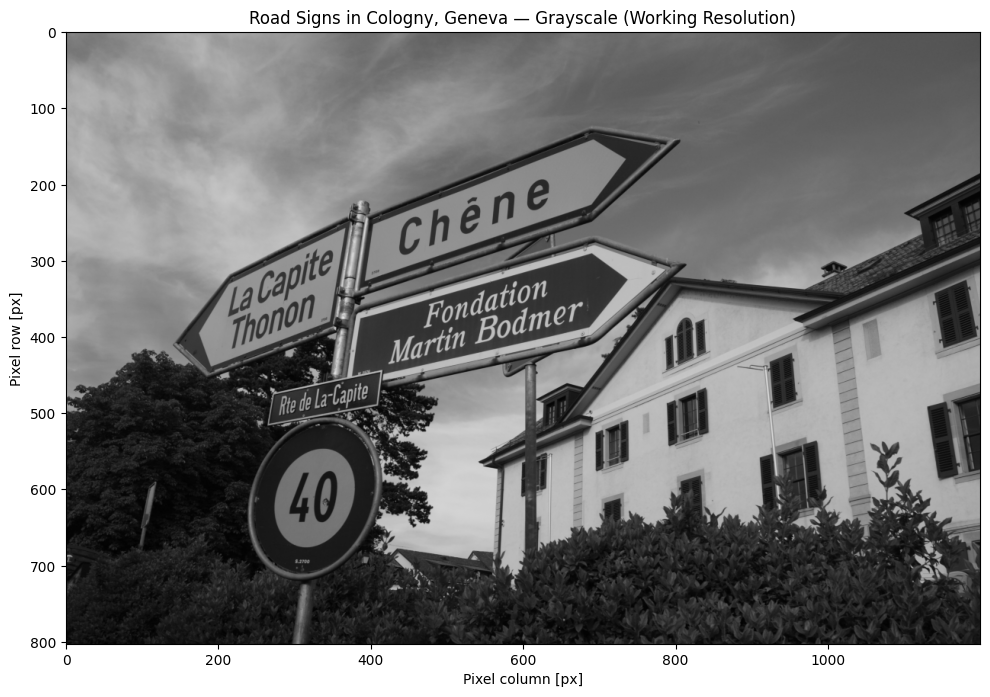

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from skimage import io, color, transform

IMAGE_FILENAME = "signpost_in_geneva.jpg"
IMAGE_SOURCE = "Wikimedia Commons, CC BY-SA 3.0, File:Signpost_in_front_of_Le_Manoir,_Cologny,_Geneva,_Switzerland_-_20140614.JPG"
RESIZE_WIDTH_PX = 1200
RNG_SEED = 26

project_root = Path.cwd().resolve().parent
image_path = project_root / "data" / IMAGE_FILENAME

img_raw = io.imread(image_path)
img_gray_full = color.rgb2gray(img_raw).astype(np.float64)

scale = RESIZE_WIDTH_PX / img_gray_full.shape[1]
new_height = int(img_gray_full.shape[0] * scale)
IMG = transform.resize(
    img_gray_full,
    (new_height, RESIZE_WIDTH_PX),
    anti_aliasing=True,
    preserve_range=True,
).astype(np.float64)

print(f"Source: {IMAGE_SOURCE}")
print(f"Original shape: {img_raw.shape}")
print(f"Working shape:  {IMG.shape}, dtype: {IMG.dtype}")
print(f"Intensity range: [{IMG.min():.4f}, {IMG.max():.4f}]")

fig, ax = plt.subplots(1, 1, figsize=(10, 7))
ax.imshow(IMG, cmap="gray", vmin=0.0, vmax=1.0)
ax.set_title("Road Signs in Cologny, Geneva — Grayscale (Working Resolution)")
ax.set_xlabel("Pixel column [px]")
ax.set_ylabel("Pixel row [px]")
plt.tight_layout()
plt.show()

**Observations:**  
The working image (1200 px wide, grayscale float64 in [0, 1]) shows a cluster of Swiss road signs photographed in Cologny, Geneva. The speed limit sign "40" is clearly visible in the lower portion of the frame with a high-contrast circular boundary (red border → dark ring in grayscale) and a large black numeral on a white background. The directional signs contain readable text of varying sizes. The bright sky background provides strong contrast against the sign edges. At this resolution, the numeral "40" and all sign text are fully legible, establishing a clean baseline for measuring augmentation-induced degradation.

## Day 2 - Methodological Design

### Theoretical Foundation and Augmentation Strategy

Two augmentation procedures are selected, both operating in the spatial domain.

**Augmentation 1 — Additive Gaussian Noise:**  
Gaussian noise is modelled as $\hat{I}(x,y) = I(x,y) + \epsilon$, where $\epsilon \sim \mathcal{N}(0, \sigma_{\text{noise}}^2)$ is independently sampled at each pixel and the result is clipped to [0, 1]. This models photon shot noise and thermal readout noise of camera sensors operating under low-light or adverse weather conditions. For road sign recognition, noise is particularly damaging to small text: pixel-level intensity perturbations can break the local contrast gradients at character boundaries, causing numerals to merge with the sign background and become unrecognisable.

**Augmentation 2 — Gaussian Blur:**  
Gaussian blur convolves the image with a Gaussian kernel $G_{\sigma}(x,y) = \frac{1}{2\pi\sigma^2}e^{-\frac{x^2+y^2}{2\sigma^2}}$, implemented via `scipy.ndimage.gaussian_filter`. This models atmospheric light scattering caused by fog or rain, which attenuates high-frequency spatial components and reduces edge sharpness. For the speed limit sign, blur progressively smears the sharp boundary between the numeral strokes and the white background, reducing the local contrast that character recognition algorithms rely on.

**Application order:** Noise is applied first (sensor-level phenomenon), followed by blur (atmospheric/optical phenomenon). This order mirrors the physical image formation process.

### Parameter Definition

**Parameter 1 — Noise standard deviation** $\sigma_{\text{noise}} \in \mathbb{R}_{>0}$, unitless (normalised intensity [0, 1]):  
Controls the amplitude of intensity perturbations per pixel. At $\sigma_{\text{noise}} = 0.02$, perturbations are visually subtle; at $\sigma_{\text{noise}} = 0.10$, local contrast at character boundaries is substantially degraded and thin numeral strokes become difficult to distinguish from the background.

**Parameter 2 — Blur standard deviation** $\sigma_{\text{blur}} \in \mathbb{R}_{>0}$, in pixels:  
Controls the spatial extent of the Gaussian kernel; effective radius $\approx 3\sigma_{\text{blur}}$ pixels. The stroke width of the numeral "4" in the sign is approximately 8–10 px at working resolution. At $\sigma_{\text{blur}} = 1.0$ (radius ~3 px), only sub-pixel detail is attenuated. At $\sigma_{\text{blur}} = 4.0$ (radius ~12 px), the blur radius exceeds the stroke width, causing strokes to merge and the numeral to become unrecognisable.

### Experimental Design

Three configurations are defined. The two parameters are varied jointly because in realistic fog conditions both atmospheric scattering (blur) and reduced photon count (noise) increase simultaneously — varying them independently would not reflect the coherent physical degradation model.

| Configuration | Label | $\sigma_{\text{noise}}$ | $\sigma_{\text{blur}}$ [px] | Simulated condition |
|---|---|---|---|---|
| Baseline | `baseline` | 0.02 | 1.0 | Near-clean camera output, minimal degradation |
| Config 1 | `config_1` | 0.05 | 2.0 | Moderate fog with light sensor noise |
| Config 2 | `config_2` | 0.10 | 4.0 | Dense fog with strong sensor noise |

The baseline represents the minimum plausible degradation (no real-world camera is perfectly noise-free). Config 1 and Config 2 progressively simulate worsening alpine weather conditions, with Config 2 representing a visibility level at which ASTRA would issue road access restrictions.

### Methodological Limitations

The joint noise-blur parameterisation assumes a fixed proportional relationship between atmospheric and sensor degradation, which may not hold across all real-world conditions (e.g., sensor noise can be high even in clear weather due to hardware defects). Additionally, Gaussian blur is only a first-order approximation of atmospheric scattering; real fog produces spatially non-uniform degradation that a homogeneous Gaussian kernel cannot capture. The SSIM metric assumes that the clean image is available as a reference, which is not the case in deployment — this limits the direct operational applicability of the evaluation.

## Day 3 - Technical Implementation

### Implementation and Verification

Augmentation functions are first verified on a synthetic test image (a white rectangle on a black background) before being applied to the Geneva road signs image. This allows visual confirmation that noise adds pixel-level intensity variance and blur reduces edge sharpness, independent of the complexity of the actual image.

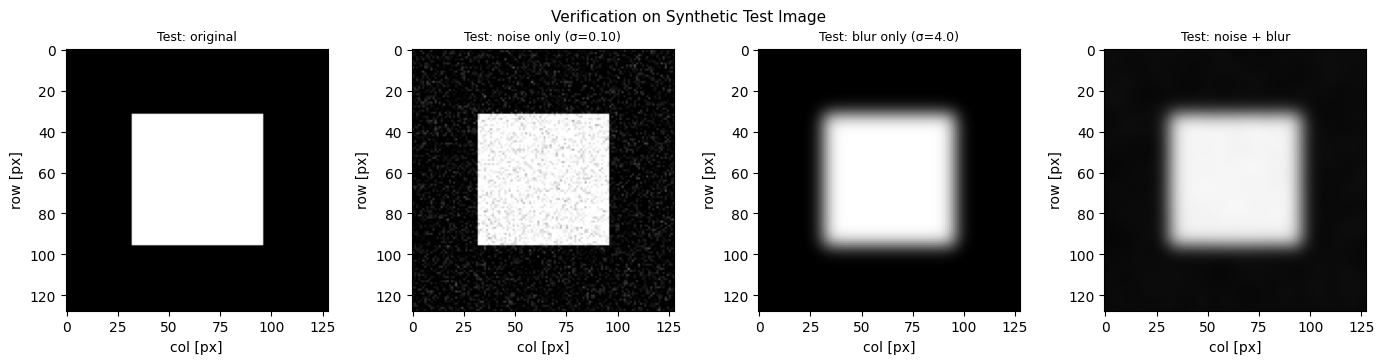

Verification passed.


In [2]:
from scipy.ndimage import gaussian_filter

CONFIGS = [
    {"label": "baseline", "sigma_noise": 0.02, "sigma_blur": 1.0},
    {"label": "config_1", "sigma_noise": 0.05, "sigma_blur": 2.0},
    {"label": "config_2", "sigma_noise": 0.10, "sigma_blur": 4.0},
]
TEST_IMG_SIZE = 128


def add_gaussian_noise(img: np.ndarray, sigma: float, rng: np.random.Generator) -> np.ndarray:
    return np.clip(img + rng.normal(0.0, sigma, img.shape), 0.0, 1.0)


def apply_gaussian_blur(img: np.ndarray, sigma: float) -> np.ndarray:
    return gaussian_filter(img, sigma=sigma)


def augment(img: np.ndarray, sigma_noise: float, sigma_blur: float, rng: np.random.Generator) -> np.ndarray:
    noisy = add_gaussian_noise(img, sigma_noise, rng)
    return apply_gaussian_blur(noisy, sigma_blur)


test_img = np.zeros((TEST_IMG_SIZE, TEST_IMG_SIZE), dtype=np.float64)
test_img[32:96, 32:96] = 1.0

rng_test = np.random.default_rng(RNG_SEED)
test_noisy = add_gaussian_noise(test_img, sigma=0.10, rng=rng_test)
test_blurred = apply_gaussian_blur(test_img, sigma=4.0)
test_augmented = augment(test_img, sigma_noise=0.10, sigma_blur=4.0, rng=np.random.default_rng(RNG_SEED))

assert test_noisy.min() >= 0.0 and test_noisy.max() <= 1.0, "Noise output out of [0, 1] range"
assert test_blurred[30, 64] > 0.0, "Blur should spread intensity beyond the rectangle boundary"
assert not np.allclose(test_augmented, test_img), "Augmented image should differ from clean input"

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
titles = ["Test: original", "Test: noise only (σ=0.10)", "Test: blur only (σ=4.0)", "Test: noise + blur"]
images = [test_img, test_noisy, test_blurred, test_augmented]
for ax, img_t, title in zip(axes, images, titles):
    ax.imshow(img_t, cmap="gray", vmin=0.0, vmax=1.0)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("col [px]")
    ax.set_ylabel("row [px]")
plt.suptitle("Verification on Synthetic Test Image", fontsize=11)
plt.tight_layout()
plt.show()
print("Verification passed.")

### Application to Geneva Road Signs Image

baseline   | σ_noise=0.02 | σ_blur=1.0 | range=[0.0074, 0.8471]
config_1   | σ_noise=0.05 | σ_blur=2.0 | range=[0.0193, 0.8406]
config_2   | σ_noise=0.10 | σ_blur=4.0 | range=[0.0419, 0.8341]


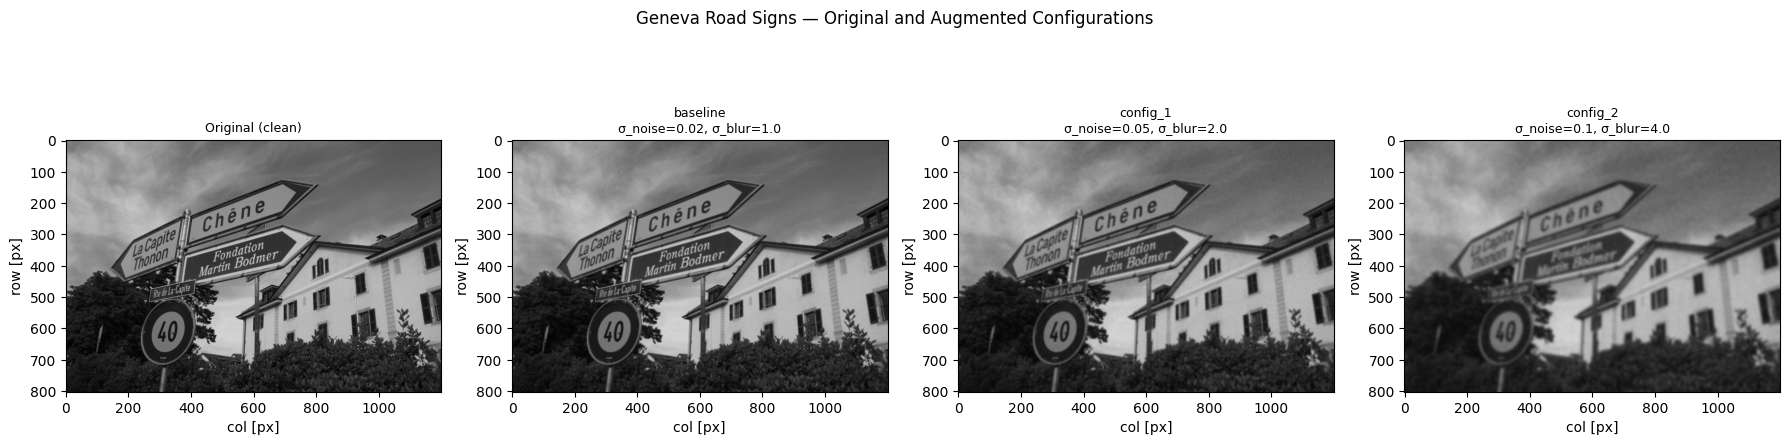

In [3]:
rng = np.random.default_rng(RNG_SEED)

augmented_images = {}
for cfg in CONFIGS:
    augmented_images[cfg["label"]] = augment(
        IMG, cfg["sigma_noise"], cfg["sigma_blur"], rng
    )
    print(
        f"{cfg['label']:10s} | σ_noise={cfg['sigma_noise']:.2f} | σ_blur={cfg['sigma_blur']:.1f} | "
        f"range=[{augmented_images[cfg['label']].min():.4f}, {augmented_images[cfg['label']].max():.4f}]"
    )

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
panel_labels = ["Original (clean)"] + [
    f"{c['label']}\nσ_noise={c['sigma_noise']}, σ_blur={c['sigma_blur']}" for c in CONFIGS
]
panel_images = [IMG] + [augmented_images[c["label"]] for c in CONFIGS]

for ax, img_p, title in zip(axes, panel_images, panel_labels):
    ax.imshow(img_p, cmap="gray", vmin=0.0, vmax=1.0)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("col [px]")
    ax.set_ylabel("row [px]")
plt.suptitle("Geneva Road Signs — Original and Augmented Configurations", fontsize=12)
plt.tight_layout()
plt.show()

## Day 4 - Evaluation

### Evaluation Measure Definition

The selected evaluation measure is the **Structural Similarity Index (SSIM)**, computed between each augmented image and the original clean image using `skimage.metrics.structural_similarity` with `data_range=1.0`.

SSIM combines three components — luminance similarity, contrast similarity, and structural similarity — into a single score in the range [−1, 1], where 1.0 indicates identical images. It is appropriate for this augmentation use case because:
1. **Luminance** captures whether overall brightness is preserved under noise.
2. **Contrast** captures whether the local intensity variation around sign edges and numeral strokes is maintained.
3. **Structure** captures whether the spatial arrangement of sign features (character shapes, circular boundary) is preserved.

Unlike pixel-level RMSE or PSNR, SSIM correlates better with human perception of image quality degradation, which is relevant for assessing whether automated sign recognition systems — which rely on edge contrast and spatial structure — can still function under the simulated conditions.

### Evaluation Execution

Evaluation table (SSIM vs. original):
  config  sigma_noise  sigma_blur    ssim  ssim_change_vs_baseline  ssim_change_pct
baseline      0.02000     1.00000 0.92942                  0.00000          0.00000
config_1      0.05000     2.00000 0.82889                 -0.10052        -10.81589
config_2      0.10000     4.00000 0.70840                 -0.22102        -23.77999


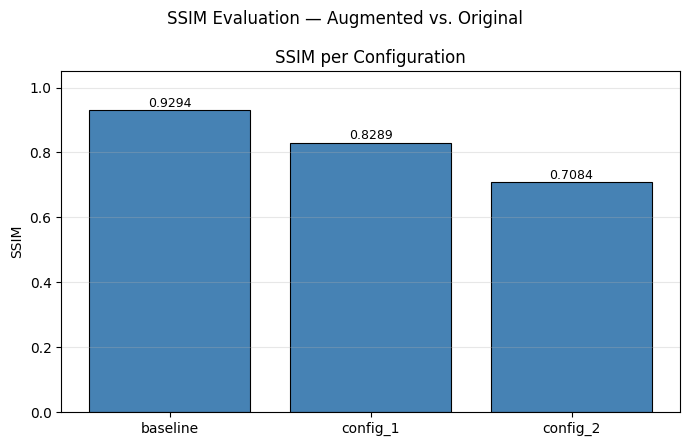

,config,sigma_noise,sigma_blur,ssim,ssim_change_vs_baseline,ssim_change_pct
0,baseline,0.02,1.0,0.929417,0.000000,0.000000
1,config_1,0.05,2.0,0.828892,-0.100525,-10.815889
2,config_2,0.10,4.0,0.708402,-0.221015,-23.779987


In [4]:
from skimage.metrics import structural_similarity

records = []
baseline_ssim = None

for cfg in CONFIGS:
    ssim_val = structural_similarity(IMG, augmented_images[cfg["label"]], data_range=1.0)
    if cfg["label"] == "baseline":
        baseline_ssim = ssim_val
    records.append({
        "config": cfg["label"],
        "sigma_noise": cfg["sigma_noise"],
        "sigma_blur": cfg["sigma_blur"],
        "ssim": ssim_val,
    })

results_df = pd.DataFrame(records)
results_df["ssim_change_vs_baseline"] = results_df["ssim"] - baseline_ssim
results_df["ssim_change_pct"] = (results_df["ssim_change_vs_baseline"] / baseline_ssim) * 100.0

print("Evaluation table (SSIM vs. original):")
print(results_df.to_string(index=False, float_format=lambda x: f"{x:.5f}"))

fig, ax = plt.subplots(1, 1, figsize=(7, 4.5))

bars = ax.bar(
    results_df["config"],
    results_df["ssim"],
    color="steelblue",
    edgecolor="black",
    linewidth=0.8,
)
for bar, val in zip(bars, results_df["ssim"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002, f"{val:.4f}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("SSIM")
ax.set_title("SSIM per Configuration")
ax.grid(axis="y", alpha=0.3)

plt.suptitle("SSIM Evaluation — Augmented vs. Original", fontsize=12)
plt.tight_layout()
plt.show()

results_df

## Day 5 - Analysis and Communication

### Observations

SSIM decreases monotonically from baseline to Config 2. The baseline configuration ($\sigma_{\text{noise}}=0.02$, $\sigma_{\text{blur}}=1.0$) yields SSIM = 0.929 relative to the original. Config 1 ($\sigma_{\text{noise}}=0.05$, $\sigma_{\text{blur}}=2.0$) produces SSIM = 0.829, a reduction of −10.8% relative to baseline. Config 2 ($\sigma_{\text{noise}}=0.10$, $\sigma_{\text{blur}}=4.0$) produces SSIM = 0.708, a reduction of −23.8% relative to baseline — the largest single-step drop in the experiment.

### Interpretation

The monotonic SSIM decrease reflects two compounding degradation mechanisms. Gaussian blur with $\sigma_{\text{blur}}=4.0$ applies an effective kernel radius of ~12 px, which exceeds the stroke width of the numeral "4" in the speed limit sign (~8–10 px at working resolution). This causes numeral strokes to merge with the background, eliminating the high-contrast edges that define character boundaries. Simultaneously, Gaussian noise at $\sigma_{\text{noise}}=0.10$ introduces random intensity offsets that disrupt the local contrast at these boundaries. Together, both effects reduce the structural and contrast components of SSIM, directly reflecting the loss of sign readability.

### Discussion and Critical Reflection

For automated Swiss road sign recognition, Config 1 (SSIM = 0.829) represents the approximate boundary of operationally acceptable image quality: sign edges remain detectable and numerals are still distinguishable, though degraded. Under Config 2 conditions (SSIM = 0.708), the numeral "40" is no longer reliably readable, meaning an automated system would fail to identify the speed limit — a safety-critical failure. A practical implication is that monitoring systems could use an SSIM-based quality pre-filter: images falling below SSIM ≈ 0.83 vs. a stored reference should be flagged for re-capture rather than processed. A key limitation is that SSIM requires a clean reference image unavailable in deployment. Additionally, the uniform Gaussian model does not capture spatially non-uniform fog, which degrades near-field and far-field signs differently.